##### 4. Train and fine-tune an SVM regressor on the California housing dataset. You can use the original dataset rather than the tweaked version we used in Chapter 2, which you can load using sklearn.datasets.fetch_california_housing(). The targets represent hundreds of thousands of dollars. Since there are over 20,000 instances, SVMs can be slow, so for hyperparameter tuning you shoulduse far fewer instances (e.g., 2,000) to test many more hyperparameter combinations. What is your best model’s RMSE?


In [78]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import uniform
import numpy as np


In [79]:
data= fetch_california_housing()
df= pd.DataFrame(data.data, columns= data.feature_names)
df['Target']= data.target

In [80]:
df=df.sample(2000, random_state= 42)
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
16491,3.2750,17.0,5.461369,1.059603,1649.0,3.640177,37.93,-121.05,1.565
16931,3.7422,42.0,5.019078,1.074722,1603.0,2.548490,37.57,-122.31,2.926
16899,5.6206,44.0,4.843750,0.934028,736.0,2.555556,37.59,-122.34,3.864
17142,4.4688,43.0,5.353247,1.135065,817.0,2.122078,37.45,-122.18,4.602
6494,4.2750,35.0,5.337176,1.031700,1414.0,4.074928,34.08,-118.01,1.736


In [81]:
df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 20046 to 13188
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      2000 non-null   float64
 1   HouseAge    2000 non-null   float64
 2   AveRooms    2000 non-null   float64
 3   AveBedrms   2000 non-null   float64
 4   Population  2000 non-null   float64
 5   AveOccup    2000 non-null   float64
 6   Latitude    2000 non-null   float64
 7   Longitude   2000 non-null   float64
 8   Target      2000 non-null   float64
dtypes: float64(9)
memory usage: 156.2 KB


In [82]:
X= df.iloc[:, :-1]
y= df.iloc[:, -1]

In [83]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=42)

In [84]:
pipeline= make_pipeline(
    StandardScaler(),
    SVR()
)

In [85]:
param_grid={
    'svr__kernel': ['rbf', 'linear'],
    'svr__C': uniform(1,50),
    'svr__epsilon': uniform(0.1, 1),
    'svr__gamma': ['scale', 'auto']
}

In [86]:
model= RandomizedSearchCV(
    pipeline, param_grid, random_state= 42, n_iter= 50, cv=3, scoring='neg_root_mean_squared_error'
)

In [87]:
model.fit(X_train, y_train)
best_model= model.best_estimator_
print(best_model)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr',
                 SVR(C=np.float64(6.502596226383838),
                     epsilon=np.float64(0.32793516254194166), gamma='auto'))])


In [88]:
print(model.best_params_)
print(model.best_score_)

{'svr__C': np.float64(6.502596226383838), 'svr__epsilon': np.float64(0.32793516254194166), 'svr__gamma': 'auto', 'svr__kernel': 'rbf'}
-0.6241027889036714


In [89]:
best_model.fit(X_train, y_train)
y_pred= best_model.predict(X_test)
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

Root Mean Squared Error: 0.5648021411665445


In [90]:
result= pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(result)

       Actual  Predicted
14677   2.430   2.751908
9992    1.388   1.051852
6492    1.663   1.583626
15888   1.853   1.440198
18687   2.286   2.185446
...       ...        ...
13829   1.516   1.227462
16631   1.896   2.195968
19797   0.496   0.620353
18169   2.438   2.610302
15893   1.920   1.519215

[400 rows x 2 columns]


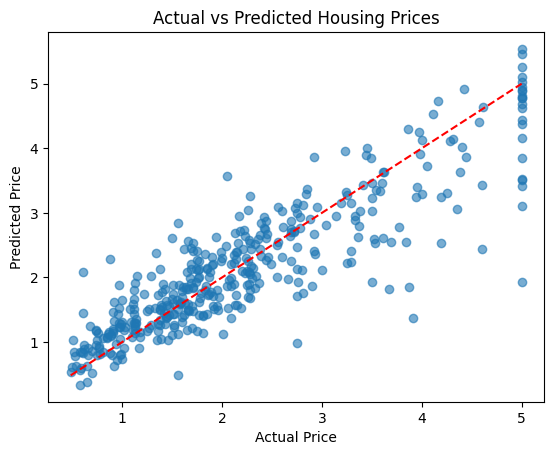

In [91]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Housing Prices")
plt.show()